# Environment Setup

In [1]:
# Debugging: Use to toggle on/off print statements for debugging.
# True: debug_messages will print 
# False: debug_messages will not print.
DEBUG = True
PACKAGES_INSTALLED = True # Set to True once packages are installed so they don't rerun.

def debug_print(*args, **kwargs):
# print(message)
    if DEBUG:
        print(*args, **kwargs)

def debug_display(df, name=None):
# display(df)
    if DEBUG:
        if name:
            print(f"Displaying DataFrame: {name}")
        display(df)

# When working on a code cell use normal print() / display statements. After you confirm the code is correct, change to the debug versions.

In [2]:
# Install packages

if not PACKAGES_INSTALLED:
    # Install packages
    %pip install -r requirements.txt
    debug_print("Packages installed.")
    PACKAGES_INSTALLED = True
else:
    debug_print("Packages already installed. Skipping installation.")


Packages already installed. Skipping installation.


In [3]:
# Update packages if needed
# %pip freeze > requirements.txt

In [4]:
# Import packages + load dataframe
import pandas as pd
import numpy as np

# Load CSV file into DataFrame
df = pd.read_csv('data.csv')


/var/folders/4z/n7sr27qx5h18n91g81tmnsdh0000gn/T/ipykernel_40084/701689009.py:6: DtypeWarning: Columns (690,691,692,703,706,708,709,710,711,712,713,714,715,716,717,718,719,720,721,1172,1174,1185,1214) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


# Data Exploration

In [5]:
# Analyze dataframe

debug_print(list(df.columns))

['artificial_id', 'Non_SOGI_School', 'Location', 'QN1', 'QN2', 'QN3', 'QN4a', 'QN4b', 'QN4c', 'QN4d', 'QN4e', 'QN5a', 'QN5b', 'QN5c', 'QN5d', 'QN5e', 'QN6', 'QN7', 'QN8', 'QN9', 'QN10', 'QN11a', 'QN11b', 'QN11c', 'QN11d', 'QN11e', 'QN11f', 'QN11g', 'QN11h', 'QN11i', 'QN11j', 'QN11k', 'QN11l', 'QN11m', 'QN11n', 'QN12a', 'QN12b', 'QN12c', 'QN12d', 'QN12e', 'QN12f', 'QN12g', 'QN12h', 'QN12i', 'QN12j', 'QN12k', 'QN12l', 'QN12m', 'QN12n', 'QN13', 'QN14a', 'QN14b', 'QN14c', 'QN14d', 'QN14e', 'QN14f', 'QN14g', 'QN14h', 'QN14i', 'QN14j', 'QN14k', 'QN14l', 'QN14m', 'QN14n', 'QN14o', 'QN14p', 'QN15', 'QN16', 'QN17', 'QN18a_a', 'QN18a_b', 'QN18a_c', 'QN18a_d', 'QN18a_e', 'QN18a_f', 'QN18a_g', 'QN18a_h', 'QN18a_i', 'QN18a_j', 'QN18a_k', 'QN18b_a', 'QN18b_b', 'QN18b_c', 'QN18b_d', 'QN18b_e', 'QN18b_f', 'QN18b_g', 'QN18b_h', 'QN18b_i', 'QN18b_j', 'QN18c_a', 'QN18c_b', 'QN18c_c', 'QN18c_d', 'QN18c_e', 'QN18c_f', 'QN18c_g', 'QN18c_h', 'QN18c_i', 'QN18c_j', 'QN18d_a', 'QN18d_b', 'QN18d_c', 'QN18d_d', '

In [6]:
# View ranges of data in each column


for col in df.columns:
    unique_values = df[col].dropna().unique()  # Drop NaNs if you don’t want them in the list
    unique_values_list = [float(val) if isinstance(val, (float, int)) else val for val in unique_values]
    debug_print(f"{col}: {unique_values_list}")



artificial_id: ['B2100007', 'B2100018', 'B2100021', 'B2100035', 'B2100036', 'B2100049', 'B2100054', 'B2100063', 'B2100072', 'B2100077', 'B2100090', 'B2100091', 'B2100105', 'B2100108', 'B2100119', 'B2100126', 'B2100133', 'B2100144', 'B2100147', 'B2100161', 'B2100162', 'B2100175', 'B2100180', 'B2100189', 'B2100198', 'B2100203', 'B2100216', 'B2100217', 'B2100231', 'B2100234', 'B2100245', 'B2100252', 'B2100259', 'B2100270', 'B2100273', 'B2100287', 'B2100288', 'B2100301', 'B2100306', 'B2100315', 'B2100324', 'B2100329', 'B2100342', 'B2100343', 'B2100357', 'B2100360', 'B2100371', 'B2100378', 'B2100385', 'B2100396', 'B2100399', 'B2100413', 'B2100414', 'B2100427', 'B2100432', 'B2100441', 'B2100450', 'B2100455', 'B2100468', 'B2100469', 'B2100483', 'B2100486', 'B2100497', 'B2100504', 'B2100511', 'B2100522', 'B2100525', 'B2100539', 'B2100540', 'B2100553', 'B2100558', 'B2100567', 'B2100576', 'B2100581', 'B2100594', 'B2100595', 'B2100609', 'B2100612', 'B2100623', 'B2100630', 'B2100637', 'B2100648', 

# Data Cleaning / Preprocessing

### 1. Drop rows that aren't questions, or questions that have text values.

In [7]:
columns_to_keep = [col for col in df.columns if ('Q' in col or 'QN' in col) and 'TEXT' not in col]
columns_to_drop = [col for col in df.columns if col not in columns_to_keep]
df = df[columns_to_keep]

# Print dropped columns
debug_print("Dropped columns:", columns_to_drop)

Dropped columns: ['artificial_id', 'Non_SOGI_School', 'Location', 'Q11n_TEXT', 'Q12n_TEXT', 'Q14o_TEXT', 'Q18a_k_TEXT', 'Q18b_j_TEXT', 'Q18c_j_TEXT', 'Q18d_j_TEXT', 'Q18e_k_TEXT', 'Q18f_k_TEXT', 'Q18g_j_TEXT', 'Q18h_k_TEXT', 'Q18i_j_TEXT', 'Q18j_j_TEXT', 'Q18k_j_TEXT', 'Q20_TEXT', 'Q21a_h_TEXT', 'Q21b_h_TEXT', 'Q21c_h_TEXT', 'Q21d_h_TEXT', 'Q21e_h_TEXT', 'Q21f_h_TEXT', 'Q21g_h_TEXT', 'Q21h_h_TEXT', 'Q21i_h_TEXT', 'Q21j_h_TEXT', 'Q21k_h_TEXT', 'Q21l_h_TEXT', 'Q22a_l_TEXT', 'Q22b_l_TEXT', 'Q22c_l_TEXT', 'Q22d_l_TEXT', 'Q22e_l_TEXT', 'Q22f_l_TEXT', 'Q22g_l_TEXT', 'Q22h_l_TEXT', 'Q22i_l_TEXT', 'Q22j_l_TEXT', 'Q22k_l_TEXT', 'Q22l_l_TEXT', 'Q24d_TEXT', 'Q29j_TEXT', 'Q34d_TEXT', 'Q42l_TEXT', 'Q57m_TEXT', 'Q60_TEXT', 'Q70k_TEXT', 'Q79h_TEXT', 'Q82_TEXT', 'Q123i_TEXT', 'Q126g_TEXT', 'Q135e_TEXT', 'Q141_TEXT', 'Q142_TEXT', 'AGEGRP', 'SEX', 'SCHOOLTYPE', 'MRACE', 'RACE_M', 'RACE_S', 'SEXID', 'SEXID2', 'ECIGT', 'ECIGAR', 'ESLT', 'EELCIGT', 'EHOOKAH', 'EROLLCIGTS', 'EPIPE', 'ESNUS', 'EORAL', 'EBIDI

### 2. Drop all QN columns

In [8]:
columns_to_drop = [col for col in df.columns if col.startswith("QN")]
columns_to_keep = [col for col in df.columns if col.startswith("Q") and not col.startswith("QN")]
df_old = df[columns_to_drop]
df = df[columns_to_keep]

debug_print("Dropped columns:", columns_to_drop)
debug_print("\n")
debug_print("Kept columns:", columns_to_keep)


Dropped columns: ['QN1', 'QN2', 'QN3', 'QN4a', 'QN4b', 'QN4c', 'QN4d', 'QN4e', 'QN5a', 'QN5b', 'QN5c', 'QN5d', 'QN5e', 'QN6', 'QN7', 'QN8', 'QN9', 'QN10', 'QN11a', 'QN11b', 'QN11c', 'QN11d', 'QN11e', 'QN11f', 'QN11g', 'QN11h', 'QN11i', 'QN11j', 'QN11k', 'QN11l', 'QN11m', 'QN11n', 'QN12a', 'QN12b', 'QN12c', 'QN12d', 'QN12e', 'QN12f', 'QN12g', 'QN12h', 'QN12i', 'QN12j', 'QN12k', 'QN12l', 'QN12m', 'QN12n', 'QN13', 'QN14a', 'QN14b', 'QN14c', 'QN14d', 'QN14e', 'QN14f', 'QN14g', 'QN14h', 'QN14i', 'QN14j', 'QN14k', 'QN14l', 'QN14m', 'QN14n', 'QN14o', 'QN14p', 'QN15', 'QN16', 'QN17', 'QN18a_a', 'QN18a_b', 'QN18a_c', 'QN18a_d', 'QN18a_e', 'QN18a_f', 'QN18a_g', 'QN18a_h', 'QN18a_i', 'QN18a_j', 'QN18a_k', 'QN18b_a', 'QN18b_b', 'QN18b_c', 'QN18b_d', 'QN18b_e', 'QN18b_f', 'QN18b_g', 'QN18b_h', 'QN18b_i', 'QN18b_j', 'QN18c_a', 'QN18c_b', 'QN18c_c', 'QN18c_d', 'QN18c_e', 'QN18c_f', 'QN18c_g', 'QN18c_h', 'QN18c_i', 'QN18c_j', 'QN18d_a', 'QN18d_b', 'QN18d_c', 'QN18d_d', 'QN18d_e', 'QN18d_f', 'QN18d_g',

In [9]:
df.shape

(22069, 687)

### 3. Merge all multi-choice questions into one column.

In [10]:
# 3: Question 4
# N -> Not Answered
# Z -> Not Displayed
# S -> Skipped
new_column = 'Q4'
columns_to_merge = ['Q4a', 'Q4b', 'Q4c', 'Q4d', 'Q4e']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q4a,Q4b,Q4c,Q4d,Q4e
0,1,15287,3864,505,186,2279
1,NaN,6266,17689,21048,21367,19274
2,N,492,492,492,492,492
3,Z,24,24,24,24,24


,Vals,Q4
0,Q4a,15287
1,Q4b,3447
2,Q4e,1863
3,N,492
4,Q4c,353
5,"Q4b,Q4e",315
6,Q4d,114
7,"Q4c,Q4e",49
8,"Q4b,Q4c",42
9,"Q4b,Q4c,Q4d,Q4e",29


In [11]:
# 3: Question 5

new_column = 'Q5'
columns_to_merge = ['Q5a', 'Q5b', 'Q5c', 'Q5d', 'Q5e']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q5a,Q5b,Q5c,Q5d,Q5e
0,NaN,17990,17535,16187,19736,7995
1,1,2438,2893,4241,692,12433
2,N,1588,1588,1588,1588,1588
3,Z,53,53,53,53,53


,Vals,Q5
0,Q5e,10949
1,Q5c,3381
2,Q5b,2201
3,Q5a,1642
4,N,1588
5,"Q5a,Q5e",427
6,"Q5c,Q5e",418
7,Q5d,378
8,"Q5b,Q5e",344
9,"Q5a,Q5c",116


In [12]:
# 3: Question 11

new_column = 'Q11'
columns_to_merge = ['Q11a', 'Q11b', 'Q11c', 'Q11d', 'Q11e', 'Q11f', 'Q11g', 'Q11h', 'Q11i', 'Q11j', 'Q11k', 'Q11l', 'Q11m', 'Q11n']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)


,Vals,Q11a,Q11b,Q11c,Q11d,Q11e,Q11f,Q11g,Q11h,Q11i,Q11j,Q11k,Q11l,Q11m,Q11n
0,S,18518,18518,18518,18518,18518,18518,18518,18518,18518,18518,18518,18518,18518,18518
1,1,1654,780,102,91,176,176,196,396,326,458,1393,763,651,200
2,NaN,1631,2512,3190,3202,3116,3117,3097,2896,2965,2831,1897,2525,2637,3043
3,Z,213,213,213,213,213,213,213,213,213,213,213,213,213,213
4,N,42,42,42,42,42,42,42,42,42,42,42,42,42,42
5,1.0,11,4,4,3,4,3,3,4,5,7,6,8,8,53


,Vals,Q11
0,S,18518
1,Q11a,627
2,Q11k,408
3,Q11b,242
4,Z,213
...,...,...
516,"Q11a,Q11e,Q11h,Q11j,Q11l,Q11m",1
517,"Q11h,Q11i,Q11j,Q11l,Q11m",1
518,"Q11a,Q11c,Q11g,Q11l,Q11m",1
519,"Q11g,Q11h",1


In [13]:
# 3: Question 12

new_column = 'Q12'
columns_to_merge = ['Q12a', 'Q12b', 'Q12c', 'Q12d', 'Q12e', 'Q12f', 'Q12g', 'Q12h', 'Q12i', 'Q12j', 'Q12k', 'Q12l', 'Q12m', 'Q12n']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q12a,Q12b,Q12c,Q12d,Q12e,Q12f,Q12g,Q12h,Q12i,Q12j,Q12k,Q12l,Q12m,Q12n
0,S,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301
1,NaN,1043,1294,1394,1383,1353,1413,1330,1245,1275,1219,1272,874,985,1270
2,1,430,179,79,90,120,60,143,228,198,254,201,599,488,203
3,Z,219,219,219,219,219,219,219,219,219,219,219,219,219,219
4,N,76,76,76,76,76,76,76,76,76,76,76,76,76,76


,Vals,Q12
0,S,20301
1,Z,219
2,Q12l,201
3,Q12n,149
4,Q12a,147
...,...,...
289,"Q12c,Q12g,Q12j",1
290,"Q12j,Q12k,Q12l,Q12m",1
291,"Q12c,Q12f,Q12g",1
292,"Q12a,Q12b,Q12e,Q12g,Q12h,Q12k,Q12l,Q12m",1


In [14]:
debug_display(df['Q12'].head(10))

0                                                    S
1                                                 Q12l
2                                                    S
3                                                 Q12m
4                                                    S
5                                                    S
6                                                 Q12n
7    Q12a,Q12b,Q12c,Q12d,Q12e,Q12f,Q12g,Q12h,Q12i,Q...
8                                  Q12a,Q12j,Q12k,Q12l
9                                                    S
Name: Q12, dtype: object

In [15]:
# 3: Question 14

new_column = 'Q14'
columns_to_merge = ['Q14a', 'Q14b', 'Q14c', 'Q14d', 'Q14e', 'Q14f', 'Q14g', 'Q14h',
                    'Q14i', 'Q14j', 'Q14k', 'Q14l', 'Q14m', 'Q14n', 'Q14o', 'Q14p']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q14a,Q14b,Q14c,Q14d,Q14e,Q14f,Q14g,Q14h,Q14i,Q14j,Q14k,Q14l,Q14m,Q14n,Q14o,Q14p
0,S,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301
1,NaN,1396,1272,672,1209,1353,1274,1426,1356,1442,1335,1408,1375,1433,1178,1236,1144
2,Z,231,231,231,231,231,231,231,231,231,231,231,231,231,231,231,231
3,1,115,239,839,302,158,237,85,155,69,176,103,136,78,333,275,367
4,N,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26


,Vals,Q14
0,S,20301
1,Q14p,282
2,Z,231
3,Q14c,217
4,Q14o,85
...,...,...
293,"Q14f,Q14g,Q14h,Q14n",1
294,"Q14c,Q14d,Q14k,Q14l",1
295,"Q14b,Q14c,Q14d,Q14f,Q14j,Q14n,Q14p",1
296,"Q14c,Q14d,Q14j,Q14l,Q14n,Q14o",1


In [16]:
# 3: Question 18a

new_column = 'Q18a'
columns_to_merge = [
    'Q18a_a', 'Q18a_b', 'Q18a_c', 'Q18a_d', 'Q18a_e', 'Q18a_f', 'Q18a_g', 'Q18a_h', 'Q18a_i', 'Q18a_j', 'Q18a_k'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18a_a,Q18a_b,Q18a_c,Q18a_d,Q18a_e,Q18a_f,Q18a_g,Q18a_h,Q18a_i,Q18a_j,Q18a_k
0,S,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301
1,NaN,1358,1152,1132,1369,577,1393,1356,1334,972,1318,1313
2,Z,246,246,246,246,246,246,246,246,246,246,246
3,1,123,329,349,112,904,88,125,147,509,163,168
4,N,41,41,41,41,41,41,41,41,41,41,41


,Vals,Q18a
0,S,20301
1,Q18a_e,333
2,Z,246
3,"Q18a_e,Q18a_i",116
4,Q18a_i,100
...,...,...
177,"Q18a_b,Q18a_e,Q18a_g,Q18a_h,Q18a_i,Q18a_k",1
178,"Q18a_c,Q18a_e,Q18a_f",1
179,"Q18a_c,Q18a_e,Q18a_f,Q18a_g,Q18a_i",1
180,"Q18a_b,Q18a_h,Q18a_i",1


In [17]:
# 3: Question 18b

new_column = 'Q18b'
columns_to_merge = [
    'Q18b_a', 'Q18b_b', 'Q18b_c', 'Q18b_d', 'Q18b_e', 'Q18b_f', 'Q18b_g', 'Q18b_h', 'Q18b_i', 'Q18b_j',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18b_a,Q18b_b,Q18b_c,Q18b_d,Q18b_e,Q18b_f,Q18b_g,Q18b_h,Q18b_i,Q18b_j
0,S,21188,21188,21188,21188,21188,21188,21188,21188,21188,21188
1,Z,550,550,550,550,550,550,550,550,550,550
2,NaN,188,271,269,257,213,260,258,278,249,269
3,1,123,40,42,54,98,51,53,33,62,42
4,N,20,20,20,20,20,20,20,20,20,20


,Vals,Q18b
0,S,21188
1,Z,550
2,Q18b_a,72
3,Q18b_e,38
4,Q18b_j,29
...,...,...
69,"Q18b_i,Q18b_j",1
70,"Q18b_b,Q18b_d",1
71,"Q18b_f,Q18b_h",1
72,"Q18b_c,Q18b_e,Q18b_f,Q18b_i",1


In [18]:
# 3: Question 18c

new_column = 'Q18c'
columns_to_merge = [
    'Q18c_a', 'Q18c_b', 'Q18c_c', 'Q18c_d', 'Q18c_e', 'Q18c_f', 'Q18c_g', 'Q18c_h', 'Q18c_i', 'Q18c_j',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18c_a,Q18c_b,Q18c_c,Q18c_d,Q18c_e,Q18c_f,Q18c_g,Q18c_h,Q18c_i,Q18c_j
0,S,21230,21230,21230,21230,21230,21230,21230,21230,21230,21230
1,Z,633,633,633,633,633,633,633,633,633,633
2,NaN,127,155,131,169,163,169,171,173,171,169
3,1,68,40,64,26,32,26,24,22,24,26
4,N,11,11,11,11,11,11,11,11,11,11


,Vals,Q18c
0,S,21230
1,Z,633
2,Q18c_a,41
3,Q18c_c,27
4,Q18c_j,17
5,Q18c_b,13
6,Q18c_e,12
7,N,11
8,Q18c_h,9
9,"Q18c_a,Q18c_b,Q18c_c,Q18c_d,Q18c_e,Q18c_f,Q18c...",7


In [19]:
# 3: Question 18d

new_column = 'Q18d'
columns_to_merge = [
    'Q18d_a', 'Q18d_b', 'Q18d_c', 'Q18d_d', 'Q18d_e', 'Q18d_f', 'Q18d_g', 'Q18d_h', 'Q18d_i', 'Q18d_j',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18d_a,Q18d_b,Q18d_c,Q18d_d,Q18d_e,Q18d_f,Q18d_g,Q18d_h,Q18d_i,Q18d_j
0,S,21270,21270,21270,21270,21270,21270,21270,21270,21270,21270
1,Z,676,676,676,676,676,676,676,676,676,676
2,NaN,84,94,71,94,85,97,95,99,102,103
3,1,32,22,45,22,31,19,21,17,14,13
4,N,7,7,7,7,7,7,7,7,7,7


,Vals,Q18d
0,S,21270
1,Z,676
2,Q18d_c,19
3,Q18d_a,14
4,Q18d_e,13
5,Q18d_j,8
6,Q18d_f,7
7,N,7
8,Q18d_g,7
9,"Q18d_a,Q18d_b,Q18d_c,Q18d_d,Q18d_e,Q18d_f,Q18d...",6


In [20]:
# 3: Question 18e

new_column = 'Q18e'
columns_to_merge = [
    'Q18e_a', 'Q18e_b', 'Q18e_c', 'Q18e_d', 'Q18e_e', 'Q18e_f', 'Q18e_g', 'Q18e_h', 'Q18e_i', 'Q18e_j', 'Q18e_k',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18e_a,Q18e_b,Q18e_c,Q18e_d,Q18e_e,Q18e_f,Q18e_g,Q18e_h,Q18e_i,Q18e_j,Q18e_k
0,S,21069,21069,21069,21069,21069,21069,21069,21069,21069,21069,21069
1,Z,726,726,726,726,726,726,726,726,726,726,726
2,NaN,236,210,151,227,216,236,232,236,239,233,219
3,1,26,52,111,35,46,26,30,26,23,29,43
4,N,12,12,12,12,12,12,12,12,12,12,12


,Vals,Q18e
0,S,21069
1,Z,726
2,Q18e_c,60
3,Q18e_k,30
4,Q18e_e,21
...,...,...
56,"Q18e_c,Q18e_e,Q18e_i",1
57,"Q18e_a,Q18e_b,Q18e_c,Q18e_d,Q18e_e,Q18e_f,Q18e...",1
58,"Q18e_i,Q18e_j",1
59,"Q18e_b,Q18e_d,Q18e_e,Q18e_f,Q18e_h,Q18e_i",1


In [21]:
# 3: Question 18f

new_column = 'Q18f'
columns_to_merge = [
    'Q18f_a', 'Q18f_b', 'Q18f_c', 'Q18f_d', 'Q18f_e', 'Q18f_f', 'Q18f_g', 'Q18f_h', 'Q18f_i', 'Q18f_j', 'Q18f_k',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18f_a,Q18f_b,Q18f_c,Q18f_d,Q18f_e,Q18f_f,Q18f_g,Q18f_h,Q18f_i,Q18f_j,Q18f_k
0,S,21043,21043,21043,21043,21043,21043,21043,21043,21043,21043,21043
1,Z,753,753,753,753,753,753,753,753,753,753,753
2,NaN,226,208,168,232,163,226,222,230,193,239,233
3,1,32,50,90,26,95,32,36,28,65,19,25
4,N,15,15,15,15,15,15,15,15,15,15,15


,Vals,Q18f
0,S,21043
1,Z,753
2,Q18f_c,37
3,Q18f_e,35
4,Q18f_i,17
...,...,...
71,"Q18f_a,Q18f_c,Q18f_d,Q18f_e,Q18f_i",1
72,"Q18f_b,Q18f_c,Q18f_d,Q18f_e,Q18f_f,Q18f_g",1
73,"Q18f_a,Q18f_c,Q18f_e,Q18f_f,Q18f_g,Q18f_i",1
74,"Q18f_c,Q18f_i,Q18f_k",1


In [22]:
# 3: Question 18g

new_column = 'Q18g'
columns_to_merge = [
    'Q18g_a', 'Q18g_b', 'Q18g_c', 'Q18g_d', 'Q18g_e', 'Q18g_f', 'Q18g_g', 'Q18g_h', 'Q18g_i', 'Q18g_j',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18g_a,Q18g_b,Q18g_c,Q18g_d,Q18g_e,Q18g_f,Q18g_g,Q18g_h,Q18g_i,Q18g_j
0,S,21079,21079,21079,21079,21079,21079,21079,21079,21079,21079
1,Z,768,768,768,768,768,768,768,768,768,768
2,NaN,154,181,164,170,136,176,183,181,171,176
3,1,56,29,46,40,74,34,27,29,39,34
4,N,12,12,12,12,12,12,12,12,12,12


,Vals,Q18g
0,S,21079
1,Z,768
2,Q18g_e,34
3,Q18g_a,28
4,Q18g_j,25
5,Q18g_c,15
6,Q18g_d,14
7,N,12
8,Q18g_f,9
9,Q18g_i,8


In [23]:
# 3: Question 18h

new_column = 'Q18h'
columns_to_merge = [
    'Q18h_a', 'Q18h_b', 'Q18h_c', 'Q18h_d', 'Q18h_e', 'Q18h_f', 'Q18h_g', 'Q18h_h', 'Q18h_i', 'Q18h_j', 'Q18h_k',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18h_a,Q18h_b,Q18h_c,Q18h_d,Q18h_e,Q18h_f,Q18h_g,Q18h_h,Q18h_i,Q18h_j,Q18h_k
0,S,21062,21062,21062,21062,21062,21062,21062,21062,21062,21062,21062
1,Z,808,808,808,808,808,808,808,808,808,808,808
2,NaN,155,158,146,167,131,159,158,171,164,157,162
3,1,34,31,43,22,58,30,31,18,25,32,27
4,N,10,10,10,10,10,10,10,10,10,10,10


,Vals,Q18h
0,S,21062
1,Z,808
2,Q18h_e,24
3,Q18h_k,22
4,Q18h_j,15
5,Q18h_a,14
6,Q18h_f,12
7,Q18h_g,10
8,N,10
9,Q18h_c,9


In [24]:
# 3: Question 18i

new_column = 'Q18i'
columns_to_merge = [
    'Q18i_a', 'Q18i_b', 'Q18i_c', 'Q18i_d', 'Q18i_e', 'Q18i_f', 'Q18i_g', 'Q18i_h', 'Q18i_i', 'Q18i_j',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18i_a,Q18i_b,Q18i_c,Q18i_d,Q18i_e,Q18i_f,Q18i_g,Q18i_h,Q18i_i,Q18i_j
0,S,21113,21113,21113,21113,21113,21113,21113,21113,21113,21113
1,Z,823,823,823,823,823,823,823,823,823,823
2,NaN,78,108,108,106,100,107,110,113,115,114
3,1,49,19,19,21,27,20,17,14,12,13
4,N,6,6,6,6,6,6,6,6,6,6


,Vals,Q18i
0,S,21113
1,Z,823
2,Q18i_a,37
3,Q18i_e,13
4,Q18i_j,11
5,Q18i_d,9
6,Q18i_f,8
7,Q18i_b,6
8,N,6
9,Q18i_h,5


In [25]:
# 3: Question 18j

new_column = 'Q18j'
columns_to_merge = [
    'Q18j_a', 'Q18j_b', 'Q18j_c', 'Q18j_d', 'Q18j_e', 'Q18j_f', 'Q18j_g', 'Q18j_h', 'Q18j_i', 'Q18j_j',
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

,Vals,Q18j_a,Q18j_b,Q18j_c,Q18j_d,Q18j_e,Q18j_f,Q18j_g,Q18j_h,Q18j_i,Q18j_j
0,S,21110,21110,21110,21110,21110,21110,21110,21110,21110,21110
1,Z,834,834,834,834,834,834,834,834,834,834
2,NaN,88,100,99,102,92,102,102,102,101,104
3,1,30,18,19,16,26,16,16,16,17,14
4,N,7,7,7,7,7,7,7,7,7,7


,Vals,Q18j
0,S,21110
1,Z,834
2,Q18j_a,20
3,Q18j_j,13
4,Q18j_e,11
5,Q18j_g,10
6,Q18j_b,9
7,Q18j_c,7
8,N,7
9,Q18j_d,6


In [26]:
# 3: Question 21a-21l (combined for convenience)

new_columns = ['Q21a', 'Q21b', 'Q21c', 'Q21d', 'Q21e', 'Q21f', 'Q21g', 'Q21h', 'Q21i', 'Q21j', 'Q21k', 'Q21l']
columns_to_merge = [
    ['Q21a_a', 'Q21a_b', 'Q21a_c', 'Q21a_d', 'Q21a_e', 'Q21a_f', 'Q21a_g', 'Q21a_h'],
    ['Q21b_a', 'Q21b_b', 'Q21b_c', 'Q21b_d', 'Q21b_e', 'Q21b_f', 'Q21b_g', 'Q21b_h'],
    ['Q21c_a', 'Q21c_b', 'Q21c_c', 'Q21c_d', 'Q21c_e', 'Q21c_f', 'Q21c_g', 'Q21c_h'],
    ['Q21d_a', 'Q21d_b', 'Q21d_c', 'Q21d_d', 'Q21d_e', 'Q21d_f', 'Q21d_g', 'Q21d_h'],
    ['Q21e_a', 'Q21e_b', 'Q21e_c', 'Q21e_d', 'Q21e_e', 'Q21e_f', 'Q21e_g', 'Q21e_h'],
    ['Q21f_a', 'Q21f_b', 'Q21f_c', 'Q21f_d', 'Q21f_e', 'Q21f_f', 'Q21f_g', 'Q21f_h'],
    ['Q21g_a', 'Q21g_b', 'Q21g_c', 'Q21g_d', 'Q21g_e', 'Q21g_f', 'Q21g_g', 'Q21g_h'],
    ['Q21h_a', 'Q21h_b', 'Q21h_c', 'Q21h_d', 'Q21h_e', 'Q21h_f', 'Q21h_g', 'Q21h_h'],
    ['Q21i_a', 'Q21i_b', 'Q21i_c', 'Q21i_d', 'Q21i_e', 'Q21i_f', 'Q21i_g', 'Q21i_h'],
    ['Q21j_a', 'Q21j_b', 'Q21j_c', 'Q21j_d', 'Q21j_e', 'Q21j_f', 'Q21j_g', 'Q21j_h'],
    ['Q21k_a', 'Q21k_b', 'Q21k_c', 'Q21k_d', 'Q21k_e', 'Q21k_f', 'Q21k_g', 'Q21k_h'],
    ['Q21l_a', 'Q21l_b', 'Q21l_c', 'Q21l_d', 'Q21l_e', 'Q21l_f', 'Q21l_g', 'Q21l_h']
]

for new_column, merge_columns in zip(new_columns, columns_to_merge):
    df[new_column] = np.nan

    # Flatten value counts for individual columns in the current group
    original_column_values = pd.concat(
        [df[col].value_counts(dropna=False).rename(f"{col}") for col in merge_columns],
        axis=1
    ).reset_index().rename(columns={'index': 'Vals'})

    for index, row in df.iterrows():
        selected_options = []
        if any(row[col] == 'S' for col in merge_columns):
            df.at[index, new_column] = 'S'
        elif any(row[col] == 'N' for col in merge_columns):
            df.at[index, new_column] = 'N'
        elif any(row[col] == 'Z' for col in merge_columns):
            df.at[index, new_column] = 'Z'
        else:
            for col in merge_columns:
                try:
                    if float(row[col]) == 1.0:
                        selected_options.append(col)
                except (ValueError, TypeError):
                    continue
            if selected_options:
                df.at[index, new_column] = ','.join(selected_options)

    df = df.drop(columns=merge_columns)

    new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
    new_column_values.columns = ['Vals', f'{new_column}']

    debug_display(original_column_values)
    debug_display(new_column_values)


,Vals,Q21a_a,Q21a_b,Q21a_c,Q21a_d,Q21a_e,Q21a_f,Q21a_g,Q21a_h
0,S,20301,20301,20301,20301,20301,20301,20301,20301
1,NaN,1050,1038,1121,1054,958,1236,1347,1272
2,1,389,401,318,385,481,203,92,167
3,Z,262,262,262,262,262,262,262,262
4,N,67,67,67,67,67,67,67,67


,Vals,Q21a
0,S,20301
1,Z,262
2,Q21a_a,197
3,Q21a_e,190
4,Q21a_d,146
...,...,...
98,"Q21a_a,Q21a_c,Q21a_d,Q21a_e,Q21a_f,Q21a_g",1
99,"Q21a_a,Q21a_b,Q21a_d,Q21a_e,Q21a_f",1
100,"Q21a_c,Q21a_e,Q21a_f",1
101,"Q21a_a,Q21a_b,Q21a_e,Q21a_f",1


In [ ]:
# 3: Question 22a-22l (combined for convenience)

new_columns = ['Q22a', 'Q22b', 'Q22c', 'Q22d', 'Q22e', 'Q22f', 'Q22g', 'Q22h', 'Q22i', 'Q22j', 'Q22k', 'Q22l']
columns_to_merge = [
    ['Q22a_a', 'Q22a_b', 'Q22a_c', 'Q22a_d', 'Q22a_e', 'Q22a_f', 'Q22a_g', 'Q22a_h', 'Q22a_i', 'Q22a_j', 'Q22a_k', 'Q22a_l'],
    ['Q22b_a', 'Q22b_b', 'Q22b_c', 'Q22b_d', 'Q22b_e', 'Q22b_f', 'Q22b_g', 'Q22b_h', 'Q22b_i', 'Q22b_j', 'Q22b_k', 'Q22b_l'],
    ['Q22c_a', 'Q22c_b', 'Q22c_c', 'Q22c_d', 'Q22c_e', 'Q22c_f', 'Q22c_g', 'Q22c_h', 'Q22c_i', 'Q22c_j', 'Q22c_k', 'Q22c_l'],
    ['Q22d_a', 'Q22d_b', 'Q22d_c', 'Q22d_d', 'Q22d_e', 'Q22d_f', 'Q22d_g', 'Q22d_h', 'Q22d_i', 'Q22d_j', 'Q22d_k', 'Q22d_l'],
    ['Q22e_a', 'Q22e_b', 'Q22e_c', 'Q22e_d', 'Q22e_e', 'Q22e_f', 'Q22e_g', 'Q22e_h', 'Q22e_i', 'Q22e_j', 'Q22e_k', 'Q22e_l'],
    ['Q22f_a', 'Q22f_b', 'Q22f_c', 'Q22f_d', 'Q22f_e', 'Q22f_f', 'Q22f_g', 'Q22f_h', 'Q22f_i', 'Q22f_j', 'Q22f_k', 'Q22f_l'],
    ['Q22g_a', 'Q22g_b', 'Q22g_c', 'Q22g_d', 'Q22g_e', 'Q22g_f', 'Q22g_g', 'Q22g_h', 'Q22g_i', 'Q22g_j', 'Q22g_k', 'Q22g_l'],
    ['Q22h_a', 'Q22h_b', 'Q22h_c', 'Q22h_d', 'Q22h_e', 'Q22h_f', 'Q22h_g', 'Q22h_h', 'Q22h_i', 'Q22h_j', 'Q22h_k', 'Q22h_l'],
    ['Q22i_a', 'Q22i_b', 'Q22i_c', 'Q22i_d', 'Q22i_e', 'Q22i_f', 'Q22i_g', 'Q22i_h', 'Q22i_i', 'Q22i_j', 'Q22i_k', 'Q22i_l'],
    ['Q22j_a', 'Q22j_b', 'Q22j_c', 'Q22j_d', 'Q22j_e', 'Q22j_f', 'Q22j_g', 'Q22j_h', 'Q22j_i', 'Q22j_j', 'Q22j_k', 'Q22j_l'],
    ['Q22k_a', 'Q22k_b', 'Q22k_c', 'Q22k_d', 'Q22k_e', 'Q22k_f', 'Q22k_g', 'Q22k_h', 'Q22k_i', 'Q22k_j', 'Q22k_k', 'Q22k_l'],
    ['Q22l_a', 'Q22l_b', 'Q22l_c', 'Q22l_d', 'Q22l_e', 'Q22l_f', 'Q22l_g', 'Q22l_h', 'Q22l_i', 'Q22l_j', 'Q22l_k', 'Q22l_l']
]

for new_column, merge_columns in zip(new_columns, columns_to_merge):
    df[new_column] = np.nan

    # Flatten value counts for individual columns in the current group
    original_column_values = pd.concat(
        [df[col].value_counts(dropna=False).rename(f"{col}") for col in merge_columns],
        axis=1
    ).reset_index().rename(columns={'index': 'Vals'})

    for index, row in df.iterrows():
        selected_options = []
        if any(row[col] == 'S' for col in merge_columns):
            df.at[index, new_column] = 'S'
        elif any(row[col] == 'N' for col in merge_columns):
            df.at[index, new_column] = 'N'
        elif any(row[col] == 'Z' for col in merge_columns):
            df.at[index, new_column] = 'Z'
        else:
            for col in merge_columns:
                try:
                    if float(row[col]) == 1.0:
                        selected_options.append(col)
                except (ValueError, TypeError):
                    continue
            if selected_options:
                df.at[index, new_column] = ','.join(selected_options)

    df = df.drop(columns=merge_columns)

    new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
    new_column_values.columns = ['Vals', f'{new_column}']

    debug_display(original_column_values)
    debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\854255516.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q22a_a,Q22a_b,Q22a_c,Q22a_d,Q22a_e,Q22a_f,Q22a_g,Q22a_h,Q22a_i,Q22a_j,Q22a_k,Q22a_l
0,S,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301,20301
1,NaN,909,1066,1209,1367,1328,1384,1371,1367,1384,1397,1216,1306
2,1,522,365,222,64,103,47,60,64,47,34,215,125
3,Z,270,270,270,270,270,270,270,270,270,270,270,270
4,N,67,67,67,67,67,67,67,67,67,67,67,67


,Vals,Q22a
0,S,20301
1,Q22a_a,522
2,Z,270
3,Q22a_b,255
4,Q22a_l,114
...,...,...
83,"Q22a_b,Q22a_i",1
84,"Q22a_c,Q22a_h,Q22a_i",1
85,"Q22a_b,Q22a_e,Q22a_g",1
86,"Q22a_b,Q22a_c,Q22a_h,Q22a_k",1


C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\854255516.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q22b_a,Q22b_b,Q22b_c,Q22b_d,Q22b_e,Q22b_f,Q22b_g,Q22b_h,Q22b_i,Q22b_j,Q22b_k,Q22b_l
0,S,21218,21218,21218,21218,21218,21218,21218,21218,21218,21218,21218,21218
1,Z,481,481,481,481,481,481,481,481,481,481,481,481
2,NaN,212,303,301,329,313,324,330,317,332,334,318,316
3,1,142,51,53,25,41,30,24,37,22,20,36,38
4,N,16,16,16,16,16,16,16,16,16,16,16,16


...

,Vals,Q22k_a,Q22k_b,Q22k_c,Q22k_d,Q22k_e,Q22k_f,Q22k_g,Q22k_h,Q22k_i,Q22k_j,Q22k_k,Q22k_l
0,S,21110,21110,21110,21110,21110,21110,21110,21110,21110,21110,21110,21110
1,Z,834,834,834,834,834,834,834,834,834,834,834,834
2,NaN,94,95,104,107,100,97,107,105,113,107,110,104
3,1,24,23,14,11,18,21,11,13,5,11,8,14
4,N,7,7,7,7,7,7,7,7,7,7,7,7


,Vals,Q22k
0,S,21110
1,Z,834
2,Q22k_a,24
3,Q22k_b,17
4,Q22k_l,13
5,Q22k_f,11
6,Q22k_e,9
7,N,7
8,Q22k_c,6
9,Q22k_h,5


C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\854255516.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q22l_a,Q22l_b,Q22l_c,Q22l_d,Q22l_e,Q22l_f,Q22l_g,Q22l_h,Q22l_i,Q22l_j,Q22l_k,Q22l_l
0,S,21055,21055,21055,21055,21055,21055,21055,21055,21055,21055,21055,21055
1,Z,850,850,850,850,850,850,850,850,850,850,850,850
2,NaN,116,125,131,140,129,135,134,136,141,141,135,128
3,1,36,27,21,12,23,17,18,16,11,11,17,24
4,N,12,12,12,12,12,12,12,12,12,12,12,12


,Vals,Q22l
0,S,21055
1,Z,850
2,Q22l_a,36
3,Q22l_l,19
4,Q22l_b,18
5,N,12
6,Q22l_c,9
7,Q22l_e,9
8,Q22l_k,8
9,Q22l_f,8


In [ ]:
# 3: Question 24

new_column = 'Q24'
columns_to_merge = ['Q24a', 'Q24b', 'Q24c', 'Q24d']


df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\3340840253.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q24a,Q24b,Q24c,Q24d
0,S,20682,20682,20682,20682
1,NaN,567,788,595,1002
2,1,514,293,486,79
3,Z,278,278,278,278
4,N,28,28,28,28


,Vals,Q24
0,S,20682
1,Q24a,312
2,Q24c,309
3,Z,278
4,Q24b,165
5,"Q24a,Q24c",93
6,Q24d,61
7,"Q24a,Q24b,Q24c",50
8,"Q24a,Q24b",50
9,N,28


In [ ]:
# 3: Question 29

new_column = 'Q29'
columns_to_merge = ['Q29a', 'Q29b', 'Q29c', 'Q29d', 'Q29e', 'Q29f', 'Q29g', 'Q29h', 'Q29i', 'Q29j']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\2398478225.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q29a,Q29b,Q29c,Q29d,Q29e,Q29f,Q29g,Q29h,Q29i,Q29j
0,S,20746,20746,20746,20746,20746,20746,20746,20746,20746,20746
1,1,591,70,133,43,53,29,78,59,24,90
2,NaN,393,914,851,941,931,955,906,925,960,894
3,Z,309,309,309,309,309,309,309,309,309,309
4,N,30,30,30,30,30,30,30,30,30,30


,Vals,Q29
0,S,20746
1,Q29a,591
2,Z,309
3,Q29j,83
4,Q29c,59
5,Q29g,30
6,N,30
7,Q29h,28
8,Q29b,24
9,Q29e,20


In [ ]:
# 3: Question 35

new_column = 'Q35'
columns_to_merge = ['Q35a', 'Q35b', 'Q35c', 'Q35d']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\2881274988.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Q35a,Q35c' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = ','.join(selected_options)


,Vals,Q35a,Q35b,Q35c,Q35d
0,S,17780,18422,18923,17786
1,2,1393,1301,957,1874
2,1,1368,518,344,290
3,3,734,932,921,859
4,Z,436,438,438,439
5,N,358,458,486,821


,Vals,Q35
0,S,19829
1,NaN,895
2,N,628
3,Z,439
4,"Q35a,Q35b,Q35c,Q35d",75
5,Q35a,64
6,"Q35a,Q35b",43
7,"Q35a,Q35b,Q35c",26
8,Q35d,18
9,"Q35a,Q35c",17


In [ ]:
# 3: Question 42

new_column = 'Q42'
columns_to_merge = ['Q42a', 'Q42b', 'Q42c', 'Q42d', 'Q42e', 'Q42f', 'Q42g', 'Q42h', 'Q42i', 'Q42j', 'Q42k', 'Q42l']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\3036401526.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q42a,Q42b,Q42c,Q42d,Q42e,Q42f,Q42g,Q42h,Q42i,Q42j,Q42k,Q42l
0,S,21218,21218,21218,21218,21218,21218,21218,21218,21218,21218,21218,21218
1,Z,479,479,479,479,479,479,479,479,479,479,479,479
2,NaN,306,278,320,327,215,321,295,314,319,326,325,321
3,1,56,84,42,35,147,41,67,48,43,36,37,41
4,N,10,10,10,10,10,10,10,10,10,10,10,10


,Vals,Q42
0,S,21218
1,Z,479
2,Q42e,76
3,NaN,74
4,Q42l,26
...,...,...
63,"Q42e,Q42f,Q42g",1
64,"Q42b,Q42f",1
65,"Q42a,Q42c,Q42l",1
66,"Q42g,Q42i,Q42k",1


In [ ]:
# 3: Question 56

new_column = 'Q56'
columns_to_merge = ['Q56a', 'Q56b', 'Q56c', 'Q56d']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\142986795.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q56a,Q56b,Q56c,Q56d
0,S,21188,21188,21188,21188
1,Z,548,548,548,548
2,NaN,199,218,249,240
3,1,126,107,76,85
4,N,8,8,8,8


,Vals,Q56
0,S,21188
1,Z,548
2,Q56a,86
3,Q56d,85
4,Q56b,65
5,Q56c,41
6,"Q56a,Q56b,Q56c",21
7,"Q56a,Q56b",13
8,N,8
9,"Q56b,Q56c",8


In [ ]:
# 3: Question 57

new_column = 'Q57'
columns_to_merge = [
    'Q57a', 'Q57b', 'Q57c', 'Q57d', 'Q57e', 'Q57f', 'Q57g', 'Q57h', 
    'Q57i', 'Q57j', 'Q57k', 'Q57l', 'Q57m', 'Q57n'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\3239198788.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q57a,Q57b,Q57c,Q57d,Q57e,Q57f,Q57g,Q57h,Q57i,Q57j,Q57k,Q57l,Q57m,Q57n
0,S,21188,21188,21188,21188,21188,21188,21188,21188,21188,21188,21188,21188,21188,21188
1,Z,548,548,548,548,548,548,548,548,548,548,548,548,548,548
2,NaN,278,183,294,288,240,287,273,263,289,291,211,242,281,266
3,1,47,142,31,37,85,38,52,62,36,34,114,83,44,59
4,N,8,8,8,8,8,8,8,8,8,8,8,8,8,8


,Vals,Q57
0,S,21188
1,Z,548
2,Q57n,48
3,Q57b,29
4,Q57k,20
...,...,...
91,"Q57d,Q57f,Q57h",1
92,"Q57e,Q57h",1
93,"Q57b,Q57c,Q57e,Q57g,Q57h,Q57k",1
94,"Q57d,Q57h",1


In [ ]:
# 3: Question 70

new_column = 'Q70'
columns_to_merge = [
    'Q70a', 'Q70b', 'Q70c', 'Q70d', 'Q70e', 'Q70f', 'Q70g', 'Q70h', 
    'Q70i', 'Q70j', 'Q70k', 'Q70l'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\1183940019.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q70a,Q70b,Q70c,Q70d,Q70e,Q70f,Q70g,Q70h,Q70i,Q70j,Q70k,Q70l
0,S,21230,21230,21230,21230,21230,21230,21230,21230,21230,21230,21230,21230
1,Z,632,632,632,632,632,632,632,632,632,632,632,632
2,NaN,119,121,173,168,162,157,168,160,170,174,178,172
3,1,84,82,30,35,41,46,35,43,33,29,25,31
4,N,4,4,4,4,4,4,4,4,4,4,4,4


,Vals,Q70
0,S,21230
1,Z,632
2,Q70l,26
3,Q70a,25
4,Q70g,12
...,...,...
65,"Q70a,Q70b,Q70e,Q70f,Q70h,Q70k",1
66,"Q70b,Q70f",1
67,"Q70b,Q70c,Q70e,Q70g,Q70h,Q70j",1
68,"Q70a,Q70b,Q70c,Q70d,Q70e,Q70f,Q70g,Q70h,Q70i,Q70l",1


In [ ]:
# 3: Question 79

new_column = 'Q79'
columns_to_merge = [
    'Q79a', 'Q79b', 'Q79c', 'Q79d', 'Q79e', 'Q79f', 'Q79g', 'Q79h', 'Q79i'
]


df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\846955765.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'S' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'S'


,Vals,Q79a,Q79b,Q79c,Q79d,Q79e,Q79f,Q79g,Q79h,Q79i
0,S,21069,21069,21069,21069,21069,21069,21069,21069,21069
1,Z,726,726,726,726,726,726,726,726,726
2,NaN,241,234,216,221,233,141,234,249,200
3,1,25,32,50,45,33,125,32,17,66
4,N,8,8,8,8,8,8,8,8,8


,Vals,Q79
0,S,21069
1,Z,726
2,Q79f,70
3,Q79i,58
4,"Q79c,Q79f",17
5,Q79d,15
6,Q79b,13
7,"Q79d,Q79f",11
8,Q79e,10
9,Q79c,10


In [ ]:
# 3: Question 88

new_column = 'Q88'
columns_to_merge = ['Q88a', 'Q88b', 'Q88c', 'Q88d', 'Q88e', 'Q88f']

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\157748106.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Q88c,Q88f' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = ','.join(selected_options)


,Vals,Q88a,Q88b,Q88c,Q88d,Q88e,Q88f
0,S,21079,21079,21079,21079,21079,21079
1,Z,768,768,768,768,768,768
2,NaN,139,111,149,178,187,171
3,1,78,106,68,39,30,46
4,N,5,5,5,5,5,5


,Vals,Q88
0,S,21079
1,Z,768
2,Q88b,53
3,Q88a,30
4,Q88c,28
5,Q88f,17
6,Q88d,15
7,"Q88a,Q88b,Q88c,Q88d,Q88e,Q88f",13
8,Q88e,10
9,"Q88a,Q88b",9


In [ ]:
# 3: Question 123

new_column = 'Q123'
columns_to_merge = [
    'Q123a', 'Q123b', 'Q123c', 'Q123d', 'Q123e', 'Q123f', 'Q123g', 'Q123h', 'Q123i'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\3669171139.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Z' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'Z'


,Vals,Q123a,Q123b,Q123c,Q123d,Q123e,Q123f,Q123g,Q123h,Q123i
0,NaN,10631,5894,6655,4836,11697,10113,11433,7067,12171
1,S,7824,7824,7824,7824,7824,7824,7824,7824,7824
2,1,2172,6909,6148,7967,1106,2690,1370,5736,632
3,Z,1128,1128,1128,1128,1128,1128,1128,1128,1128
4,N,314,314,314,314,314,314,314,314,314


,Vals,Q123
0,S,7824
1,Z,1128
2,Q123d,1084
3,"Q123b,Q123c,Q123d",923
4,Q123h,897
...,...,...
306,"Q123d,Q123e,Q123i",1
307,"Q123c,Q123d,Q123e,Q123f,Q123h,Q123i",1
308,"Q123a,Q123f,Q123i",1
309,"Q123e,Q123f,Q123g,Q123h,Q123i",1


In [ ]:
# 3: Question 126

new_column = 'Q126'
columns_to_merge = [
    'Q126a', 'Q126b', 'Q126c', 'Q126d', 'Q126e', 'Q126f', 'Q126g'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\2011534432.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Z' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'Z'


,Vals,Q126a,Q126b,Q126c,Q126d,Q126e,Q126f,Q126g
0,NaN,12846,15560,11968,11599,14762,12441,15562
1,1,5002,2288,5880,6249,3086,5407,2286
2,S,2174,2174,2174,2174,2174,2174,2174
3,Z,1189,1189,1189,1189,1189,1189,1189
4,N,858,858,858,858,858,858,858


,Vals,Q126
0,Q126a,2242
1,S,2174
2,Q126d,1957
3,Q126c,1839
4,Q126f,1814
...,...,...
111,"Q126b,Q126c,Q126f,Q126g",1
112,"Q126b,Q126c,Q126d,Q126e,Q126g",1
113,"Q126b,Q126d,Q126e,Q126g",1
114,"Q126b,Q126d,Q126f,Q126g",1


In [ ]:
# 3: Question 135

new_column = 'Q135'
columns_to_merge = [
    'Q135a', 'Q135b', 'Q135c', 'Q135d', 'Q135e', 'Q135f'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\3632101562.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Z' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'Z'


,Vals,Q135a,Q135b,Q135c,Q135d,Q135e,Q135f
0,NaN,12281,16965,17249,15690,19221,10200
1,1,7759,3075,2791,4350,819,9840
2,Z,1428,1428,1428,1428,1428,1428
3,N,601,601,601,601,601,601


,Vals,Q135
0,Q135f,9840
1,Q135a,3728
2,Z,1428
3,"Q135a,Q135b,Q135c,Q135d",1363
4,Q135d,960
5,"Q135a,Q135d",830
6,N,601
7,"Q135a,Q135b",446
8,Q135b,428
9,Q135e,419


In [ ]:
# 3: Question 136

new_column = 'Q136'
columns_to_merge = [
    'Q136a', 'Q136b', 'Q136c', 'Q136d', 'Q136e', 'Q136f', 'Q136g', 'Q136h', 
    'Q136i', 'Q136j', 'Q136k', 'Q136l', 'Q136m'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\3102794233.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Z' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'Z'


,Vals,Q136a,Q136b,Q136c,Q136d,Q136e,Q136f,Q136g,Q136h,Q136i,Q136j,Q136k,Q136l,Q136m
0,NaN,17099,16131,18580,18475,19275,19033,19125,19048,19191,19109,19274,19006,6016
1,1,2332,3300,851,956,156,398,306,383,240,322,157,425,13415
2,Z,1449,1449,1449,1449,1449,1449,1449,1449,1449,1449,1449,1449,1449
3,N,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189


,Vals,Q136
0,Q136m,13415
1,Q136b,1724
2,Z,1449
3,N,1189
4,Q136a,944
...,...,...
337,"Q136a,Q136b,Q136e,Q136l",1
338,"Q136a,Q136b,Q136d,Q136k",1
339,"Q136a,Q136h,Q136i,Q136j,Q136k,Q136l",1
340,"Q136a,Q136c,Q136d,Q136i,Q136l",1


In [ ]:
# 3: Question 137

new_column = 'Q137'
columns_to_merge = [
    'Q137a', 'Q137b', 'Q137c', 'Q137d', 'Q137e', 'Q137f', 'Q137g', 'Q137h', 
    'Q137i', 'Q137j', 'Q137k', 'Q137l', 'Q137m', 'Q137n', 'Q137o'
]

df[new_column] = np.nan

original_column_values = pd.concat([df[col].value_counts(dropna=False).rename(col) for col in columns_to_merge], axis=1)
original_column_values = original_column_values.reset_index().rename(columns={'index': 'Vals'})

for index, row in df.iterrows():
    selected_options = []
    if any(row[col] == 'S' for col in columns_to_merge):
        df.at[index, new_column] = 'S'
    elif any(row[col] == 'N' for col in columns_to_merge):
        df.at[index, new_column] = 'N'
    elif any(row[col] == 'Z' for col in columns_to_merge):
        df.at[index, new_column] = 'Z'
    else:
        for col in columns_to_merge:
            try:
                if float(row[col]) == 1.0 or float(row[col]) == 2.0:
                    selected_options.append(col)
            except (ValueError, TypeError):
                continue
        if selected_options:
            df.at[index, new_column] = ','.join(selected_options)

df = df.drop(columns=columns_to_merge)

new_column_values = pd.DataFrame(df[new_column].value_counts(dropna=False)).reset_index()
new_column_values.columns = ['Vals', f'{new_column}']

debug_display(original_column_values)
debug_display(new_column_values)

C:\Users\bryan\AppData\Local\Temp\ipykernel_10404\394031445.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Z' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[index, new_column] = 'Z'


,Vals,Q137a,Q137b,Q137c,Q137d,Q137e,Q137f,Q137g,Q137h,Q137i,Q137j,Q137k,Q137l,Q137m,Q137n,Q137o
0,2,17287,16754,15132,17527,15190,13156,16718,16773,18180,17946,14435,16428,14566,16347,16122
1,1,1964,2430,4056,1567,3929,6004,2393,2379,873,1076,4667,2587,4506,2703,2896
2,Z,1528,1528,1528,1528,1528,1528,1528,1589,1589,1589,1589,1589,1589,1589,1589
3,N,1290,1357,1353,1447,1422,1381,1430,1328,1427,1458,1378,1465,1408,1430,1462


,Vals,Q137
0,"Q137a,Q137b,Q137c,Q137d,Q137e,Q137f,Q137g,Q137...",17978
1,N,2509
2,Z,1582


Export a smaller set for better view and chatgpt use

In [ ]:
# Select the first 200 rows
# subset_df = df.head(200)

# Save the subset to a new CSV file
# subset_df.to_csv('subset_data.csv', index=False)

### 4. Handle Missing Values

In [ ]:
# Drop all the rows with missing values (those that are not N, S, or Z.)
missing_counts = df.isna().sum()

for column, count in missing_counts.items():
    if count > 0:
        debug_print(f"Column {column}: {count} missing values")

df_cleaned = df.dropna()

debug_print(f"Remaining rows in the DataFrame: {len(df_cleaned)}")

Column Q18k_a: 93 missing values
Column Q18k_b: 129 missing values
Column Q18k_c: 132 missing values
Column Q18k_d: 134 missing values
Column Q18k_e: 122 missing values
Column Q18k_f: 136 missing values
Column Q18k_g: 133 missing values
Column Q18k_h: 142 missing values
Column Q18k_i: 140 missing values
Column Q18k_j: 131 missing values
Column Q42m: 272 missing values
Column Q35: 895 missing values
Column Q42: 74 missing values
Remaining rows in the DataFrame: 20780


### 5. Create Target Feature

In [ ]:
# Target feature: Q_target: 1 => User, 2 => Non-user 
df['Q_target'] = df['Q100'].apply(
    lambda x: 1 if (pd.to_numeric(x, errors='coerce') in range(1, 31) or x == 'N') else (2 if x == 'S' else None)
)

df = df.dropna(subset=['Q_target'])
df = df.drop(columns=['Q100'])
q_target_counts = df['Q_target'].value_counts()

debug_print(f"Counts in Q_target:\n{q_target_counts}")
debug_print(f"Remaining rows in the DataFrame: {len(df)}")


Counts in Q_target:
Q_target
2.0    19341
1.0     1877
Name: count, dtype: int64
Remaining rows in the DataFrame: 21218


In [ ]:
# Target feature: Q_target: 1 => User, 2 => Non-user
df_cleaned['Q_target'] = df_cleaned['Q100'].apply(
    lambda x: 1 if (pd.to_numeric(x, errors='coerce') in range(1, 31) or x == 'N') else (2 if x == 'S' else None)
)

# Drop rows with NaN values in the Q_target column
df_cleaned = df_cleaned.dropna(subset=['Q_target'])

# Drop the original Q100 column since it's no longer needed
df_cleaned = df_cleaned.drop(columns=['Q100'])

# Check the counts in the new target column
q_target_counts = df_cleaned['Q_target'].value_counts()

debug_print(f"Counts in Q_target:\n{q_target_counts}")
debug_print(f"Remaining rows in the DataFrame: {len(df_cleaned)}")


Counts in Q_target:
Q_target
2.0    18605
1.0     1388
Name: count, dtype: int64
Remaining rows in the DataFrame: 19993


Encoding for Q4

In [ ]:
import numpy as np
import pandas as pd

# Step 1: Calculate the mean target value for each unique value in Q4
encoding_map_Q4 = df_cleaned.groupby('Q4')['Q_target'].mean()

# Step 2: Sort the encoding map to see which values are more predictive of being a user (Q_target = 1)
encoding_map_Q4 = encoding_map_Q4.sort_values(ascending=False)
print("\nTarget Encoding Map for Q4:")
print(encoding_map_Q4)

# Step 3: Apply the encoding map to create a new column with encoded values
df_cleaned['Q4_encoded'] = df_cleaned['Q4'].map(encoding_map_Q4)

# Step 4: Display the value counts of the new encoded column to check the transformation
print("\nEncoded Q4 column Value Counts:")
print(df_cleaned['Q4_encoded'].value_counts(dropna=False))

# Step 5: Display the first few rows to verify the encoding
print("\nFirst Few Rows:")
print(df_cleaned[['Q4', 'Q4_encoded', 'Q_target']].head(10))



Target Encoding Map for Q4:
Q4
Q4d,Q4e            2.000000
Q4b,Q4c,Q4d        2.000000
Q4c,Q4d,Q4e        2.000000
Q4a                1.934724
Q4e                1.929901
Q4b                1.925828
Q4b,Q4e            1.925000
N                  1.918269
Q4c,Q4d            1.900000
Q4c,Q4e            1.897436
Q4c                1.884488
Q4b,Q4d            1.875000
Q4d                1.827586
Q4b,Q4c            1.815789
Q4b,Q4c,Q4e        1.666667
Q4b,Q4c,Q4d,Q4e    1.647059
Q4b,Q4d,Q4e        1.000000
Name: Q_target, dtype: float64

Encoded Q4 column Value Counts:
Q4_encoded
1.934724    14140
1.925828     3020
1.929901     1612
1.918269      416
1.884488      303
1.925000      280
1.827586       87
1.897436       39
1.815789       38
1.647059       17
2.000000       13
1.900000       10
1.666667        9
1.875000        8
1.000000        1
Name: count, dtype: int64

First Few Rows:
             Q4  Q4_encoded  Q_target
0           Q4a    1.934724       1.0
4           Q4a    1.934724 

Target Encoding Map for Q4:

This part shows the average Q_target value for each unique combination found in the Q4 column.
The encoding map is sorted in descending order of the mean Q_target value:
Higher values (closer to 2.0) indicate combinations that are more associated with non-users.
Lower values (closer to 1.0) indicate combinations that are more associated with users.


Encoded Q4 Column Value Counts:

This section displays how many rows fall into each of the encoded values.
For example, the value 1.934724 appears 14140 times, meaning there are 14140 rows with that specific encoded value.




Don't understand why there are so many Q4a instnaces in the First Few Rows table/columns. 
    - apparently Q4a might be the most frequently selected option, or it might correlate more strognly with users (Q_target = 1)
    - The presense of so many Q4a indicates that many respondents chose this option
    - The encoding value (1.934724) represents the mean target value for rows where only Q4a was selected

Do the same encoding process to the rest of the merged/created columns 

In [ ]:
import numpy as np
import pandas as pd

# List of merged columns to encode
columns_to_encode = [
    'Q5', 'Q11', 'Q12', 'Q14', 'Q18a', 'Q18b', 'Q18c', 'Q18d', 'Q18e', 'Q18f', 
    'Q18g', 'Q18h', 'Q18i', 'Q18j', 'Q21a', 'Q21b', 'Q21c', 'Q21d', 'Q21e', 'Q21f', 
    'Q21g', 'Q21h', 'Q21i', 'Q21j', 'Q21k', 'Q21l', 'Q22a', 'Q22b', 'Q22c', 'Q22d', 
    'Q22e', 'Q22f', 'Q22g', 'Q22h', 'Q22i', 'Q22j', 'Q22k', 'Q22l', 'Q24', 'Q29', 
    'Q35', 'Q42', 'Q56', 'Q57', 'Q70', 'Q79', 'Q88', 'Q123', 'Q126', 'Q135', 
    'Q136', 'Q137'
]

# Function to encode each column using the Q_target values
def target_encode_column(df, column):
    # Step 1: Calculate the mean target value for each unique value in the column
    encoding_map = df.groupby(column)['Q_target'].mean()
    
    # Step 2: Sort the encoding map to see which values are more predictive
    encoding_map = encoding_map.sort_values(ascending=False)
    print(f"\nTarget Encoding Map for {column}:\n{encoding_map}")
    
    # Step 3: Apply the encoding map to create a new column with encoded values
    encoded_column = f"{column}_encoded"
    df[encoded_column] = df[column].map(encoding_map)
    
    # Display value counts for the encoded column
    print(f"\nEncoded {encoded_column} column Value Counts:")
    print(df[encoded_column].value_counts(dropna=False))
    
    # Step 4: Drop the original column after encoding
    df.drop(columns=[column], inplace=True)
    
    return df

# Apply the encoding process for each column in the list
for col in columns_to_encode:
    df_cleaned = target_encode_column(df_cleaned, col)

# Display the first few rows of the encoded dataframe to verify
print("\nFirst Few Rows After Encoding:")
print(df_cleaned.head(10))



Target Encoding Map for Q5:
Q5
Q5a,Q5b,Q5c,Q5d        2.000000
Q5c,Q5d,Q5e            2.000000
Q5a,Q5b,Q5d            2.000000
Q5a,Q5b,Q5d,Q5e        2.000000
Q5a,Q5c,Q5d            2.000000
Q5b,Q5c,Q5d,Q5e        2.000000
Q5b                    1.973672
Q5b,Q5e                1.965625
Q5b,Q5d,Q5e            1.964286
Q5a,Q5d                1.956522
Q5b,Q5d                1.955556
Q5a,Q5b                1.948718
Q5c,Q5d                1.945946
N                      1.939372
Q5d                    1.938511
Q5e                    1.931198
Q5c                    1.927181
Q5a,Q5c                1.917526
Q5d,Q5e                1.905660
Q5a                    1.896601
Q5c,Q5e                1.884932
Q5a,Q5b,Q5e            1.882353
Q5a,Q5d,Q5e            1.875000
Q5b,Q5c,Q5e            1.875000
Q5a,Q5e                1.867532
Q5b,Q5c                1.851351
Q5a,Q5b,Q5c,Q5d,Q5e    1.842105
Q5a,Q5c,Q5e            1.786885
Q5a,Q5b,Q5c            1.777778
Q5b,Q5c,Q5d            1.700000
Q5a,Q5c,

Drop the column used to create the Q4_encoded

In [ ]:
df_cleaned.drop(columns=['Q4'], inplace=True)


In [ ]:
total_none = (df == 'NONE').sum().sum()
print(f"The total number of 'NONE' values in the entire dataset: {total_none}")


In [ ]:
df.isna().sum().sum()

Code to train a random forest model

Q1               object
Q2               object
Q3               object
Q6               object
Q7               object
                 ...   
Q123_encoded    float64
Q126_encoded    float64
Q135_encoded    float64
Q136_encoded    float64
Q137_encoded    float64
Length: 217, dtype: object
Model Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00       278
         2.0       1.00      1.00      1.00      3721

    accuracy                           1.00      3999
   macro avg       1.00      1.00      1.00      3999
weighted avg       1.00      1.00      1.00      3999



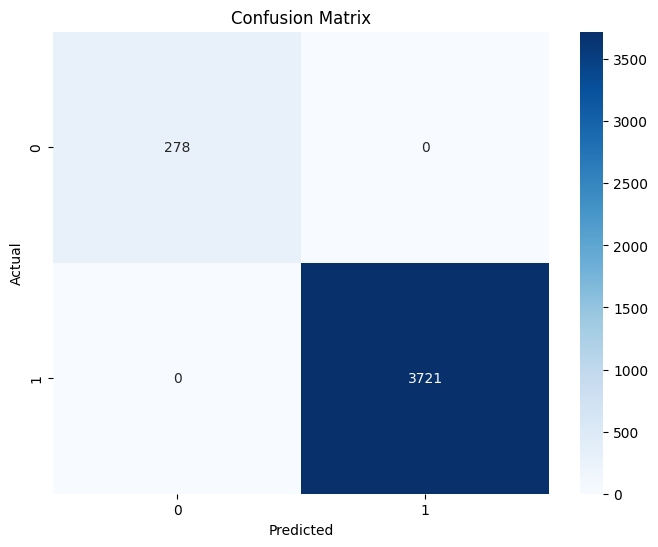


Top 10 Features by Importance:
          Feature  Importance
97           Q102    0.137317
96           Q101    0.128251
98           Q103    0.111327
99           Q104    0.091159
100          Q105    0.062274
190  Q22a_encoded    0.048227
166   Q12_encoded    0.038014
26            Q26    0.036060
11            Q17    0.030903
168  Q18a_encoded    0.024910


In [ ]:
# Step 1: Replace specific string values with unique numeric values
df_cleaned.replace({
    'N': -1,   # Not Answered
    'Z': -2,   # Not Displayed
    'S': -3,   # Skipped
    'E': -4,   # Missing due to edit checks
    '.': np.nan  # Missing data remains NaN for imputation
}, inplace=True)

# Step 2: Handle missing values ('.')
df_cleaned.fillna(0, inplace=True)  # Or use another imputation strategy if needed

# Step 3: Confirm that the data is now numeric
print(df_cleaned.dtypes)

# Step 4: Proceed with your existing model training code
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split data into features (X) and target (y)
X = df_cleaned.drop(columns=['Q_target'])
y = df_cleaned['Q_target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
feature_importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("\nTop 10 Features by Importance:")
print(importance_df.head(10))


probably overfitting but lets use Stratified K-Fold cross validation to determine that 

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
import numpy as np

# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Define Stratified K-Fold cross-validator with 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store the scores for each fold
accuracy_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

# Perform cross-validation
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    precision_scores.append(precision_score(y_test, y_pred, average='weighted'))
    recall_scores.append(recall_score(y_test, y_pred, average='weighted'))

# Display the cross-validation results
print("Cross-Validation Results:")
print(f"Accuracy: {np.mean(accuracy_scores):.2f} ± {np.std(accuracy_scores):.2f}")
print(f"F1-Score: {np.mean(f1_scores):.2f} ± {np.std(f1_scores):.2f}")
print(f"Precision: {np.mean(precision_scores):.2f} ± {np.std(precision_scores):.2f}")
print(f"Recall: {np.mean(recall_scores):.2f} ± {np.std(recall_scores):.2f}")


Cross-Validation Results:
Accuracy: 1.00 ± 0.00
F1-Score: 1.00 ± 0.00
Precision: 1.00 ± 0.00
Recall: 1.00 ± 0.00


Attempting Logistics regression to see if it is only because of the model

Logistic Regression Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00       278
         2.0       1.00      1.00      1.00      3721

    accuracy                           1.00      3999
   macro avg       1.00      1.00      1.00      3999
weighted avg       1.00      1.00      1.00      3999



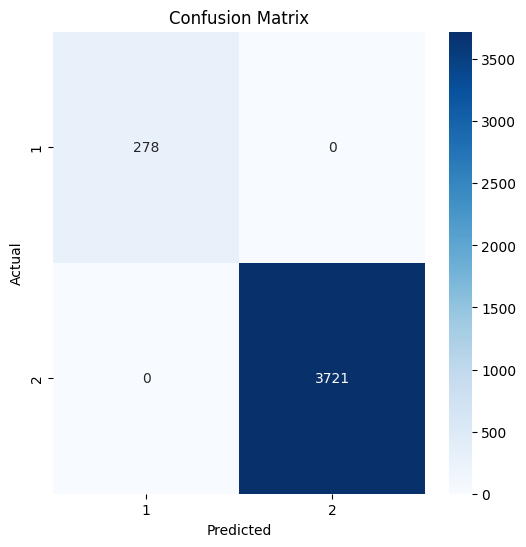


Cross-Validation Results:
Mean Accuracy: 1.00 ± 0.00
Mean F1 Score: 1.00 ± 0.00


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Prepare your data
X = df_cleaned.drop(columns=['Q_target'])  # Features (drop the target column)
y = df_cleaned['Q_target']  # Target variable

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Logistic Regression Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 6: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 7: Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = []
cv_f1 = []

for train_index, test_index in skf.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train_cv, y_train_cv)
    y_pred_cv = model.predict(X_test_cv)
    
    cv_accuracy.append(accuracy_score(y_test_cv, y_pred_cv))
    cv_f1.append(f1_score(y_test_cv, y_pred_cv, average='weighted'))

print("\nCross-Validation Results:")
print(f"Mean Accuracy: {np.mean(cv_accuracy):.2f} ± {np.std(cv_accuracy):.2f}")
print(f"Mean F1 Score: {np.mean(cv_f1):.2f} ± {np.std(cv_f1):.2f}")


check for correlation for each feature

In [ ]:
# Calculate correlation of all features with the target variable, excluding 'Q_target'
correlation_with_target = df_cleaned.drop(columns=['Q_target']).corrwith(df_cleaned['Q_target']).sort_values(ascending=False)

print("Correlation with Target Variable (excluding Q_target itself):")
print(correlation_with_target)


Correlation with Target Variable (excluding Q_target itself):
Q21a_encoded    0.867584
Q22a_encoded    0.867584
Q12_encoded     0.867584
Q14_encoded     0.867584
Q18a_encoded    0.867584
                  ...   
Q104           -0.921088
Q103           -0.931569
Q102           -0.931623
Q105           -0.970868
Q101           -0.989427
Length: 216, dtype: float64


attempting RandomForest, overSampler, and underSampler after dropping -3 values

In [ ]:
exclude_column = 'Q_target'  # Specify any column to exclude from the drop process

# Check if the df_cleaned dataset contains -3 values
contains_negative_three = (df_cleaned == -3).any()

# Identify columns to drop, excluding the specified column
columns_to_drop = contains_negative_three[contains_negative_three].index.difference([exclude_column])

# Print the total columns before dropping
print(f"Total columns before dropping: {df_cleaned.shape[1]}")

# Print the columns to be dropped
if columns_to_drop.any():
    print(f"Columns dropped: {', '.join(columns_to_drop)}")
else:
    print("No columns were dropped.")

# Drop the identified columns
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

# Print the total columns after dropping
print(f"Total columns after dropping: {df_cleaned.shape[1]}")


Total columns before dropping: 217
Columns dropped: Q10, Q101, Q102, Q103, Q104, Q105, Q122, Q124, Q125, Q13, Q138a, Q138b, Q138c, Q138d, Q138e, Q138f, Q138g, Q138h, Q138i, Q138j, Q138k, Q138l, Q138m, Q138n, Q138o, Q15, Q16, Q17, Q18k_a, Q18k_b, Q18k_c, Q18k_d, Q18k_e, Q18k_f, Q18k_g, Q18k_h, Q18k_i, Q18k_j, Q19, Q20, Q23, Q25, Q26, Q27, Q28, Q30, Q31, Q32, Q33, Q37, Q38, Q39, Q40, Q41, Q42m, Q43, Q44, Q45, Q46, Q47, Q48, Q49, Q50, Q51, Q53, Q54, Q55, Q58, Q59, Q60, Q61, Q62, Q63, Q64, Q65, Q68, Q69, Q7, Q71, Q72, Q73, Q75, Q78, Q8, Q80, Q81, Q82, Q84, Q86, Q87, Q89, Q9, Q90, Q93, Q95, Q97, Q99
Total columns after dropping: 120


Now doing RandomForest model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# Step 1: Define features and target
X = df_cleaned.drop(columns=['Q_target'])  # Features
y = df_cleaned['Q_target']  # Target

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Step 4: Initialize and train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=500,          # Number of trees
    max_depth=10,              # Maximum depth of each tree (None = no limit)
    min_samples_split=2,       # Minimum number of samples required to split a node
    min_samples_leaf=1,        # Minimum number of samples required at a leaf node
    max_features='sqrt',       # Number of features to consider at each split
    random_state=42,
    class_weight='balanced'    # Balanced class weights
)
rf_model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = rf_model.predict(X_test)

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 7: Feature importance
feature_importances = rf_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)
print("Top 10 Features by Importance:\n", importance_df.head(10))


Model Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

         1.0       1.00      0.98      0.99       261
         2.0       1.00      1.00      1.00      3738

    accuracy                           1.00      3999
   macro avg       1.00      0.99      1.00      3999
weighted avg       1.00      1.00      1.00      3999

Top 10 Features by Importance:
           Feature  Importance
81   Q21a_encoded    0.106170
70    Q14_encoded    0.099309
71   Q18a_encoded    0.097692
69    Q12_encoded    0.090839
93   Q22a_encoded    0.089894
68    Q11_encoded    0.069544
106   Q29_encoded    0.057133
3              Q6    0.054696
105   Q24_encoded    0.042537
4            Q34a    0.038194
